In [2]:
import numpy as np
A = np.array([ [12, 5, 8, 20], [ 7, 15, 3, 11], [25, 9, 18, 6], [10, 14, 2, 16]])

In [3]:
A

array([[12,  5,  8, 20],
       [ 7, 15,  3, 11],
       [25,  9, 18,  6],
       [10, 14,  2, 16]])

1. Calculate the mean of each row.

In [4]:
row = np.mean(A, axis=1)
print(row)

[11.25  9.   14.5  10.5 ]


2. Replace every element that is greater than its row mean by 1.

In [5]:
result = (A > row[:, None]) * 1
print(result)

[[1 0 0 1]
 [0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]]


In [6]:
result = np.where(A > row[:, None], 1, A)

3. Replace every other element by 0.

In [7]:
result = np.where(A > row[:, None], 1, 0)

4. Return the resulting binary matrix.

In [8]:
print(result)

[[1 0 0 1]
 [0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]]


5. Also determine which row contains the maximum number of elements
above its row mean.

In [9]:
count = np.sum(result, axis=1)
maxi = np.max(count)
row_max = np.where(count == maxi)[0]

print(row_max)

[0 1 2 3]


In [10]:
X = np.array([ [10, 100, 5], [12, 110, 6], [11, 105, 7], [13, 500, 6], [14, 108, 8], [15,
115, 9] ])

For each column:
1. Calculate the mean and standard deviation.

In [11]:
mean=np.mean(X,axis=0)
std=np.std(X,axis=0)
print(mean)
print(std)

[ 12.5        173.           6.83333333]
[  1.70782513 146.31017281   1.34370962]


2. Identify values satisfying:
∣x−μ∣>2σ

In [12]:
ans=np.abs(X-mean)>2*std
print(ans)

[[False False False]
 [False False False]
 [False False False]
 [False  True False]
 [False False False]
 [False False False]]


3. Replace such values with the corresponding column median.

In [13]:
median = np.median(X, axis=0)
result = np.where(ans, median, X)

print(result)

[[ 10. 100.   5.]
 [ 12. 110.   6.]
 [ 11. 105.   7.]
 [ 13. 109.   6.]
 [ 14. 108.   8.]
 [ 15. 115.   9.]]


4. Do this without modifying non-outlier values.

In [14]:
median = np.median(X,axis=0)
result = np.where(ans,median,X)

print(result)

[[ 10. 100.   5.]
 [ 12. 110.   6.]
 [ 11. 105.   7.]
 [ 13. 109.   6.]
 [ 14. 108.   8.]
 [ 15. 115.   9.]]


In [15]:
import pandas as pd

df = pd.DataFrame({
    'Student': ['A','B','C','D','E','F','G','H'],
    'Department': ['CSE','CSE','ECE','ECE','CSE','ECE','CSE','ECE'],
    'Gender': ['F','M','F','M','M','F','F','M'],
    'Marks': [85,72,91,65,78,88,95,70],
    'Attendance': [92,81,96,72,85,90,98,75]
})

1. Average marks for each department.

In [16]:
avg_marks = df.groupby('Department')['Marks'].mean()
print(avg_marks)

Department
CSE    82.5
ECE    78.5
Name: Marks, dtype: float64


2. Average marks separately for each (Department, Gender) group.

In [17]:
avg_marks = df.groupby(['Department','Gender'])['Marks'].mean()
print(avg_marks)

Department  Gender
CSE         F         90.0
            M         75.0
ECE         F         89.5
            M         67.5
Name: Marks, dtype: float64


3. Student with the highest marks in each department.

In [18]:
highest = df.loc[df.groupby('Department')['Marks'].idxmax()]
print(highest)

  Student Department Gender  Marks  Attendance
6       G        CSE      F     95          98
2       C        ECE      F     91          96


4. Students whose marks are above their department average.

In [19]:
avg = df.groupby('Department')['Marks'].transform('mean')
result = df[df['Marks'] > avg]
print(result)

  Student Department Gender  Marks  Attendance
0       A        CSE      F     85          92
2       C        ECE      F     91          96
5       F        ECE      F     88          90
6       G        CSE      F     95          98


5. Department having the highest average attendance.

In [20]:
avg = df.groupby('Department')['Attendance'].mean()
print(avg.idxmax())

CSE


In [21]:
df = pd.DataFrame({
    'ID': [101,102,103,101,104,102,105],
    'Name': ['A','B','C','A','D','B','E'],
    'Age': [20,21,22,20,23,21,24],
    'Score': [80,75,90,85,88,75,92]
})

1. Identify duplicated IDs.

In [22]:
print(df['ID'][df['ID'].duplicated()].values)

[101 102]


2. For each ID, determine whether its records are identical.

In [23]:
result = df.groupby('ID').nunique().max(axis=1) == 1
print(result)

ID
101    False
102     True
103     True
104     True
105     True
dtype: bool


3. If multiple records exist for an ID, retain the record having the highest Score.

In [24]:
result = df.loc[df.groupby('ID')['Score'].idxmax()]
print(result)

    ID Name  Age  Score
3  101    A   20     85
1  102    B   21     75
2  103    C   22     90
4  104    D   23     88
6  105    E   24     92


4. Produce a clean DataFrame containing exactly one record per ID.

In [25]:
print(result)

    ID Name  Age  Score
3  101    A   20     85
1  102    B   21     75
2  103    C   22     90
4  104    D   23     88
6  105    E   24     92


5. Report how many records were removed.

In [26]:
removed = len(df) - len(result)
print(removed)

2


In [27]:
df = pd.DataFrame({
    'Date': ['2026-01-01','2026-01-02','2026-01-04','2026-01-05','2026-01-08','2026-01-09'],
    'Sales': [100,120,150,130,180,200]
})

1. Convert Date into a proper datetime column.

In [28]:
df['Date'] = pd.to_datetime(df['Date'])
print(df)

        Date  Sales
0 2026-01-01    100
1 2026-01-02    120
2 2026-01-04    150
3 2026-01-05    130
4 2026-01-08    180
5 2026-01-09    200


2. Detect the missing dates.

In [29]:
dates = pd.date_range(df['Date'].min(), df['Date'].max())
missing = dates.difference(df['Date'])
print(missing)

DatetimeIndex(['2026-01-03', '2026-01-06', '2026-01-07'], dtype='datetime64[ns]', freq=None)


3. Reindex the DataFrame to contain every date between the minimum and maximum date.
4. Keep missing sales as NaN.

In [30]:
dates = pd.date_range(df['Date'].min(), df['Date'].max())
df = df.set_index('Date').reindex(dates)
print(df)

            Sales
2026-01-01  100.0
2026-01-02  120.0
2026-01-03    NaN
2026-01-04  150.0
2026-01-05  130.0
2026-01-06    NaN
2026-01-07    NaN
2026-01-08  180.0
2026-01-09  200.0


5. Calculate a 3-day rolling average of sales.

In [31]:
df['Rolling_Avg'] = df['Sales'].rolling(3).mean()
print(df)

            Sales  Rolling_Avg
2026-01-01  100.0          NaN
2026-01-02  120.0          NaN
2026-01-03    NaN          NaN
2026-01-04  150.0          NaN
2026-01-05  130.0          NaN
2026-01-06    NaN          NaN
2026-01-07    NaN          NaN
2026-01-08  180.0          NaN
2026-01-09  200.0          NaN


6. Identify the date on which the rolling average is maximum.

In [32]:
print(df['Rolling_Avg'].idxmax())

NaT


/tmp/ipykernel_3177/2201975608.py:1: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  print(df['Rolling_Avg'].idxmax())


In [33]:
P = np.array([
    [1, 2],
    [4, 6],
    [7, 3],
    [2, 8],
    [9, 5]
])

Q6. Construct a 5×5 matrix where element (i,j) contains the Euclidean distance between points i and j. The solution must: ● use NumPy broadcasting; ● contain no for or while loop; ● have zeros on the diagonal; ● produce a symmetric matrix. Then identify the pair of points having the maximum distance.

In [34]:
diff = P[:, np.newaxis, :] - P[np.newaxis, :, :]
distance = np.sqrt(np.sum(diff**2, axis=2))

print(distance)

max_distance = np.max(distance)
pair = np.argwhere(distance == max_distance)[0]

print("Maximum distance:", max_distance)
print("Pair of points:", pair)

[[0.         5.         6.08276253 6.08276253 8.54400375]
 [5.         0.         4.24264069 2.82842712 5.09901951]
 [6.08276253 4.24264069 0.         7.07106781 2.82842712]
 [6.08276253 2.82842712 7.07106781 0.         7.61577311]
 [8.54400375 5.09901951 2.82842712 7.61577311 0.        ]]
Maximum distance: 8.54400374531753
Pair of points: [0 4]


Q7. Take datasets from kaggle (Tabular datasets e.g. weather dataset, housing dataset, titanic dataset, etc.) Perform exploratory data analysis on the dataset using seaborn , matplotlib. (Draw graphs like bar chart, line chart, scatter plots, etc. and explain the insights). Also clean the dataset accordingly.

# **1.Titanic Dataset**

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df=pd.read_csv("Titanic-Dataset.csv")

In [37]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Performing exploratory data analysis on the dataset

In [38]:
df.shape

(891, 12)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [40]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [41]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


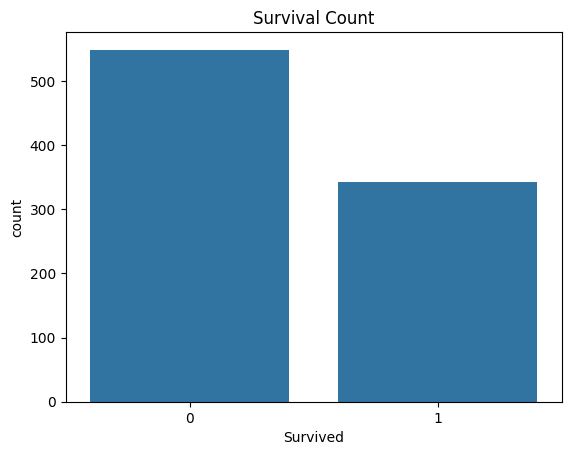

In [42]:
sns.countplot(x='Survived',data=df)
plt.title('Survival Count')
plt.show()

Insight: The number of passengers who did not survive was higher than the number of passengers who survived.

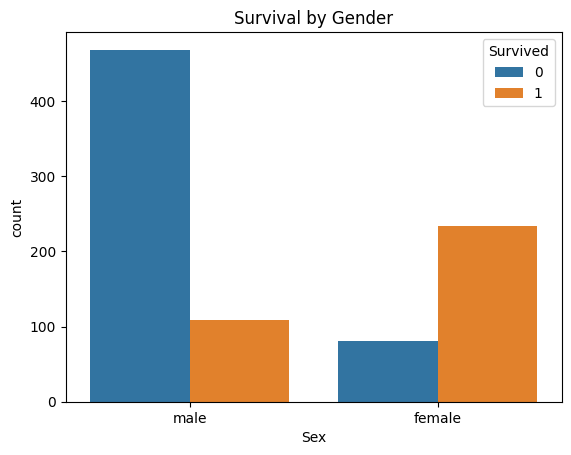

In [43]:
sns.countplot(x='Sex',hue='Survived',data=df)
plt.title('Survival by Gender')
plt.show()

Insight: Female passengers had a much higher survival rate than male passengers.

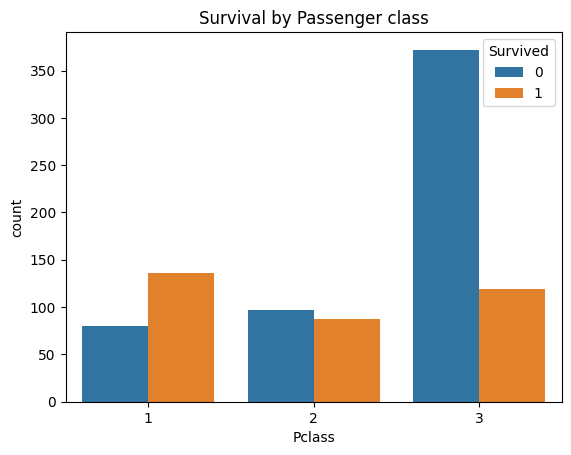

In [46]:
sns.countplot(x='Pclass',hue='Survived',data=df)
plt.title('Survival by Passenger class')
plt.show()

Insight: First-class passengers had a higher proportion of survivors, while third-class passengers had the highest number of passengers who did not survive.

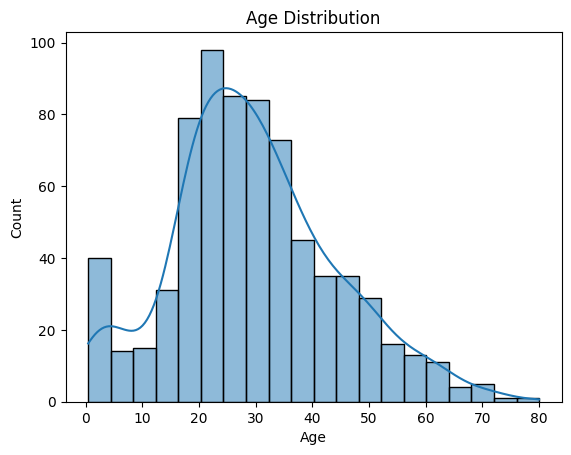

In [47]:
sns.histplot(df['Age'],bins=20,kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

Insight: Most passengers were young to middle-aged adults, with fewer very young children and elderly passengers

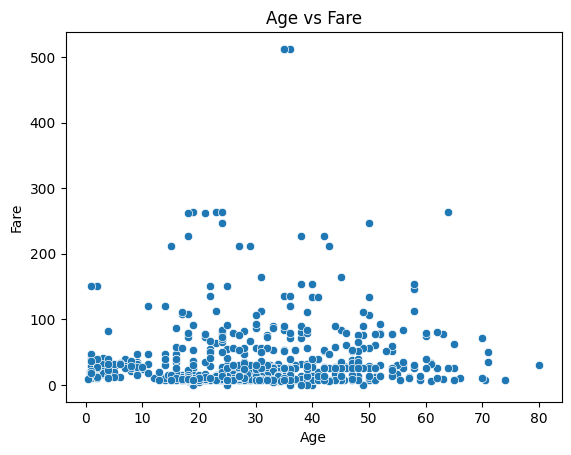

In [48]:
sns.scatterplot(x='Age', y='Fare', data=df)
plt.title('Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

Insight: Most passengers paid relatively low fares, while a small number of passengers paid very high fares. There is no clear strong relationship between age and fare.

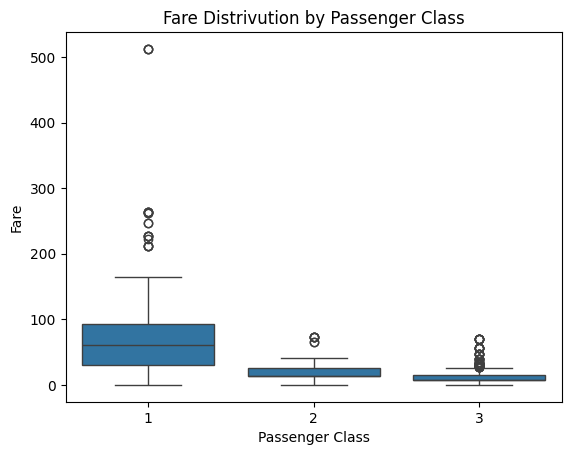

In [49]:
sns.boxplot(x='Pclass',y='Fare',data=df)
plt.title('Fare Distrivution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

Insight: First-class passengers generally paid higher fares than second- and third-class passengers.

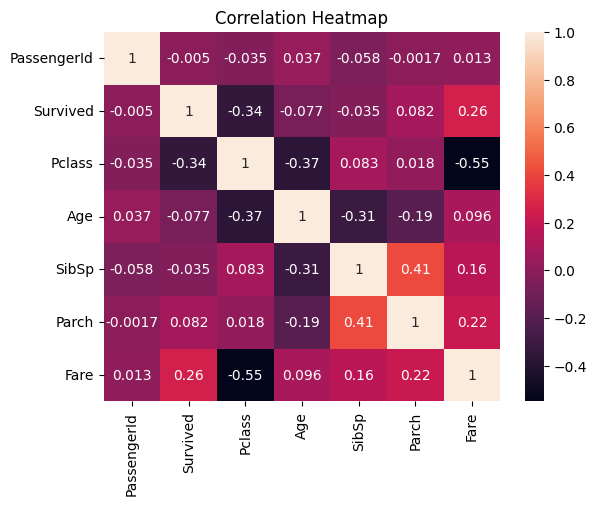

In [50]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title('Correlation Heatmap')
plt.show()

Insight: Pclass and Fare have a negative correlation, while Pclass and Survived also show a negative correlation. Most other variables have weak correlations.

In [51]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [52]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [53]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [56]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [57]:
df= df.drop('Cabin',axis=1)

In [58]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [59]:
df.duplicated().sum()

np.int64(0)

# **2.House Prices Dataset**



In [62]:
df=pd.read_csv('/content/Housing.csv')

In [63]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [64]:
df.shape

(545, 13)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [67]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [68]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


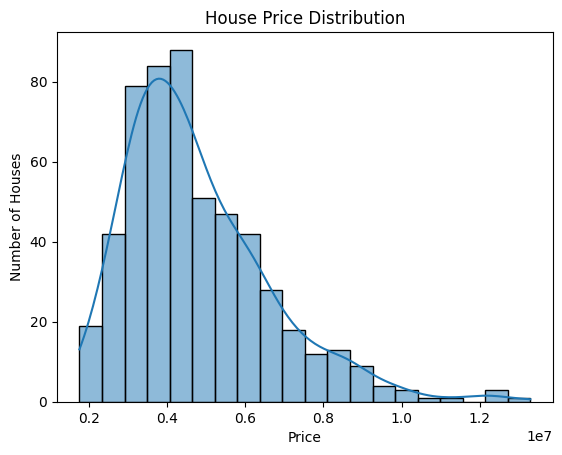

In [69]:
sns.histplot(df['price'],bins=20,kde=True)
plt.title('House Price Distribution')
plt.xlabel('Price')
plt.ylabel('Number of Houses')
plt.show()

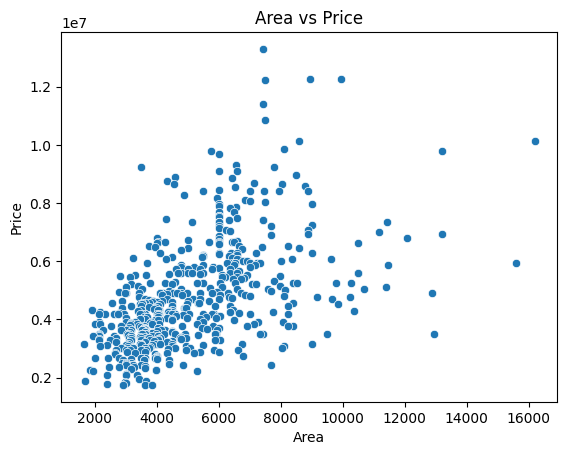

In [70]:
sns.scatterplot(x='area',y='price',data=df)
plt.title('Area vs Price')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

Insight: House price generally increases as the area of the house increases

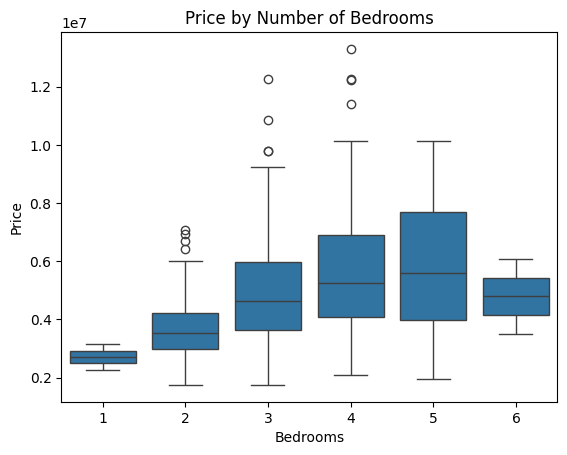

In [71]:
sns.boxplot(x='bedrooms',y='price',data=df)
plt.title('Price by Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.show()

Insight: Houses with more bedrooms generally have higher prices

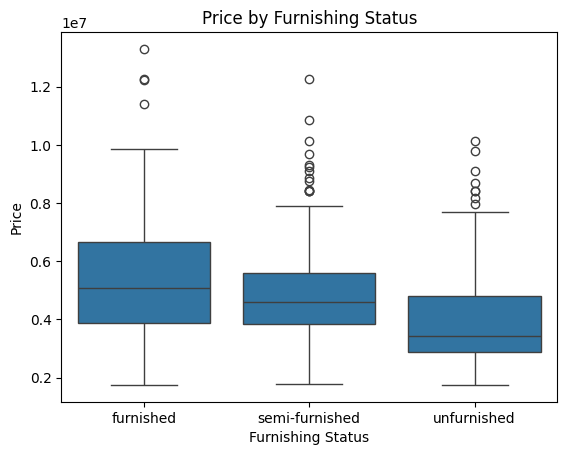

In [72]:
sns.boxplot(x='furnishingstatus', y='price', data=df)
plt.title('Price by Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Price')
plt.show()

Insight: Furnished houses generally have higher prices than semi-furnished and unfurnished houses.

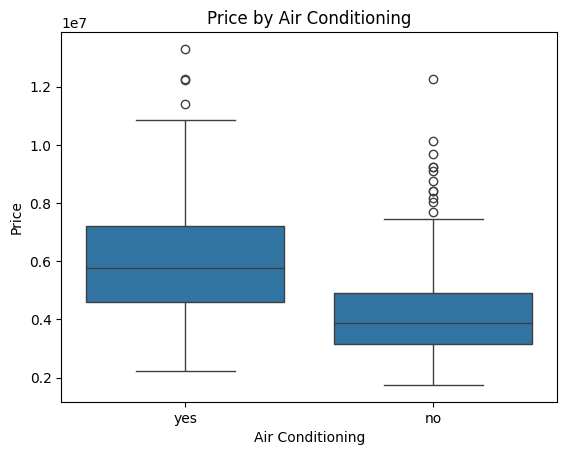

In [73]:
sns.boxplot(x='airconditioning', y='price', data=df)
plt.title('Price by Air Conditioning')
plt.xlabel('Air Conditioning')
plt.ylabel('Price')
plt.show()

Insight: Houses with air conditioning generally have higher prices than houses without it.

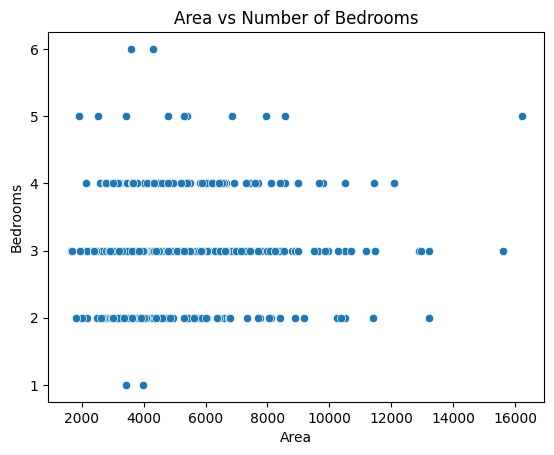

In [74]:
sns.scatterplot(x='area', y='bedrooms', data=df)
plt.title('Area vs Number of Bedrooms')
plt.xlabel('Area')
plt.ylabel('Bedrooms')
plt.show()

Insight: Larger houses generally tend to have more bedrooms

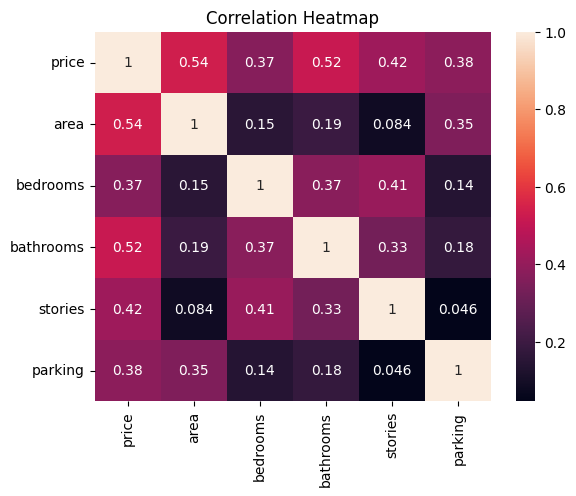

In [75]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.show()

Insight: Price has a positive correlation with area, bathrooms, and bedrooms, with area.

# **3.WEATHER DATASET**

In [80]:
df=pd.read_csv('/content/weatherHistory.csv')

In [81]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [82]:
df.shape

(96453, 12)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [84]:
df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [85]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


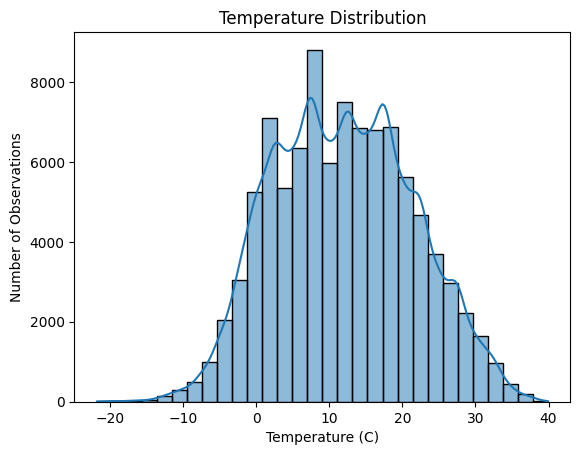

In [86]:
sns.histplot(df['Temperature (C)'], bins=30, kde=True)
plt.title('Temperature Distribution')
plt.xlabel('Temperature (C)')
plt.ylabel('Number of Observations')
plt.show()

Insight: Most temperatures are between about 0°C and 25°C, with fewer very cold or very hot observations.

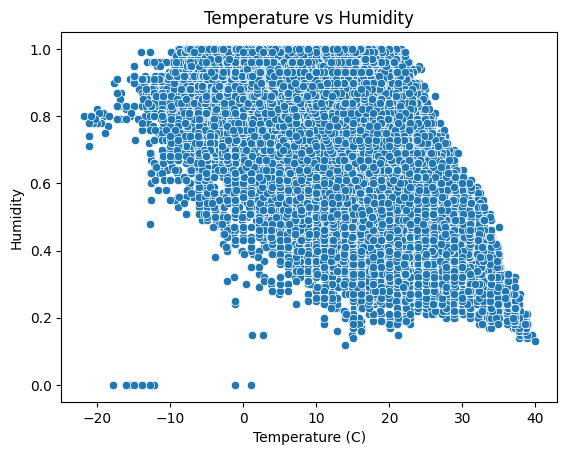

In [87]:
sns.scatterplot(x='Temperature (C)', y='Humidity', data=df)
plt.title('Temperature vs Humidity')
plt.xlabel('Temperature (C)')
plt.ylabel('Humidity')
plt.show()

Insight: Humidity varies across temperatures, but there is no very strong clear relationship between temperature and humidity.

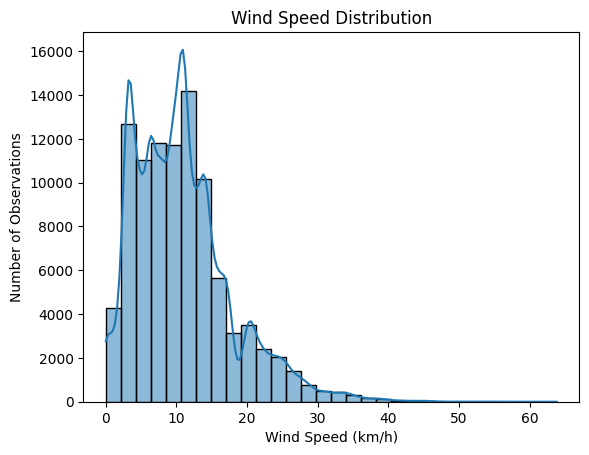

In [88]:
sns.histplot(df['Wind Speed (km/h)'], bins=30, kde=True)
plt.title('Wind Speed Distribution')
plt.xlabel('Wind Speed (km/h)')
plt.ylabel('Number of Observations')
plt.show()

Insight: Most observations have relatively low to moderate wind speeds

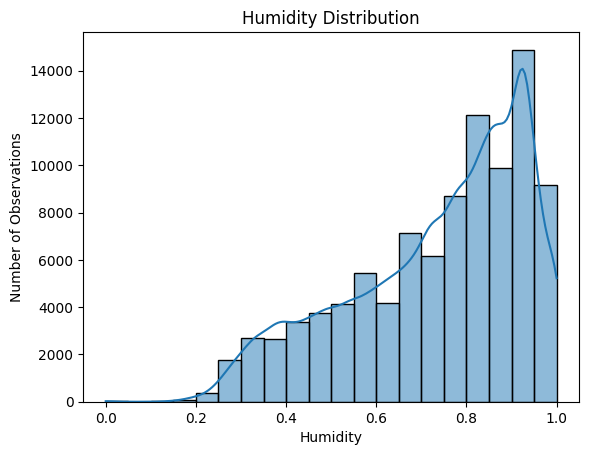

In [89]:
sns.histplot(df['Humidity'], bins=20, kde=True)
plt.title('Humidity Distribution')
plt.xlabel('Humidity')
plt.ylabel('Number of Observations')
plt.show()

Insight: Most observations have relatively high humidity, with many values concentrated between 0.6 and 1.0

In [90]:
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)

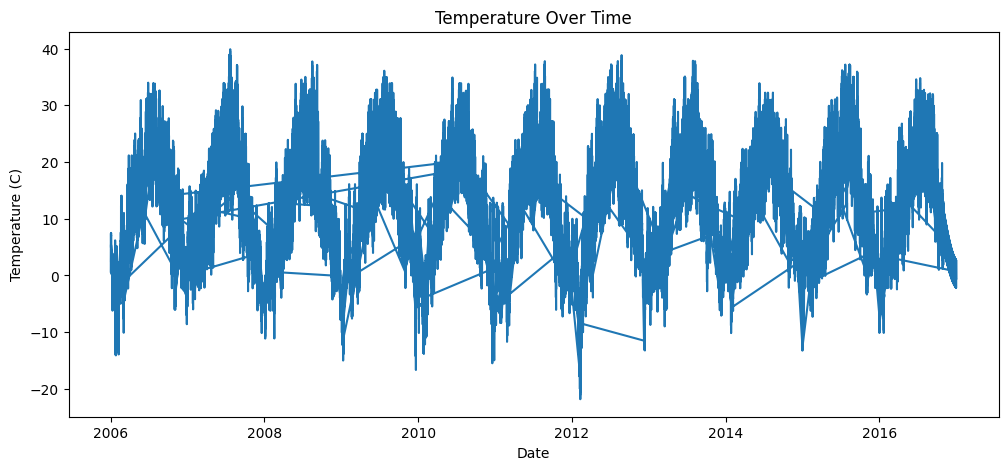

In [91]:
plt.figure(figsize=(12,5))
plt.plot(df['Formatted Date'], df['Temperature (C)'])
plt.title('Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (C)')
plt.show()

Insight: Temperature shows clear fluctuations over time.

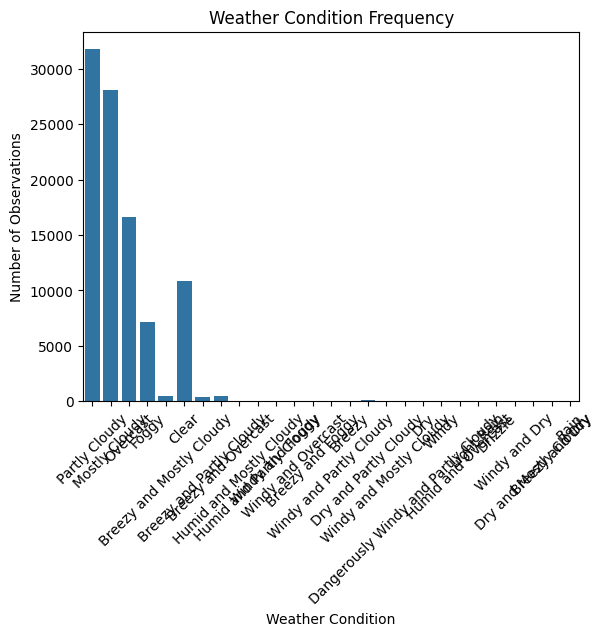

In [92]:
sns.countplot(x='Summary', data=df)
plt.title('Weather Condition Frequency')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45)
plt.show()

Insight: Partly Cloudy and Mostly Cloudy are among the most frequently observed weather conditions, while some conditions occur much less often.

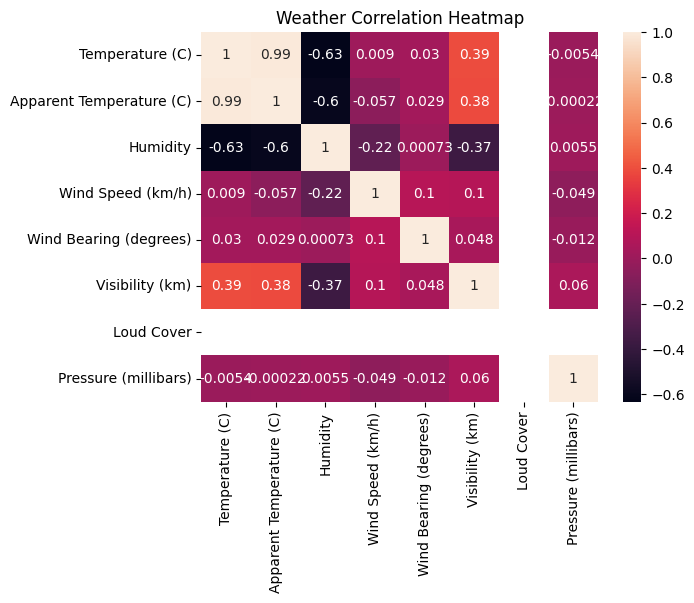

In [93]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Weather Correlation Heatmap')
plt.show()

Insight: Temperature and apparent temperature have a strong positive correlation

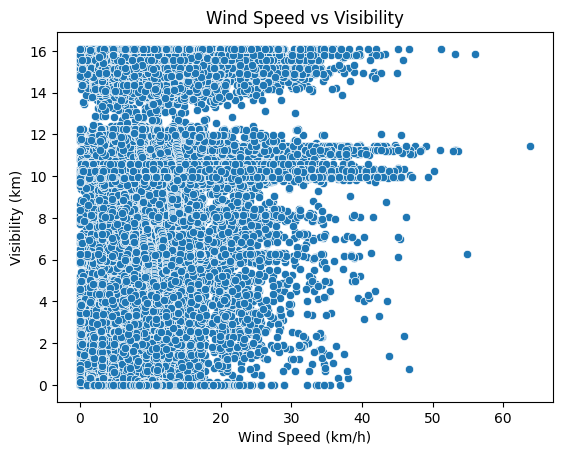

In [94]:
sns.scatterplot(x='Wind Speed (km/h)', y='Visibility (km)', data=df)
plt.title('Wind Speed vs Visibility')
plt.xlabel('Wind Speed (km/h)')
plt.ylabel('Visibility (km)')
plt.show()

Insight: Wind speed and visibility show a weak relationship

In [95]:
df['Precip Type'] = df['Precip Type'].fillna(df['Precip Type'].mode()[0])

In [96]:
df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,0
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [97]:
df = df.drop('Loud Cover', axis=1)

In [98]:
df.shape

(96453, 11)

In [99]:
df.duplicated().sum()

np.int64(24)

In [100]:
df = df.drop_duplicates()

In [101]:
df.duplicated().sum()

np.int64(0)

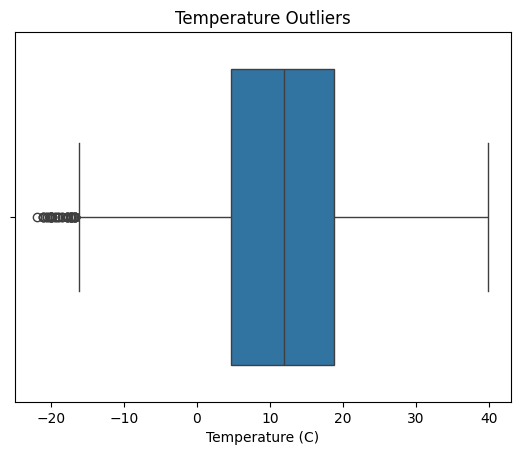

In [102]:
sns.boxplot(x=df['Temperature (C)'])
plt.title('Temperature Outliers')
plt.show()

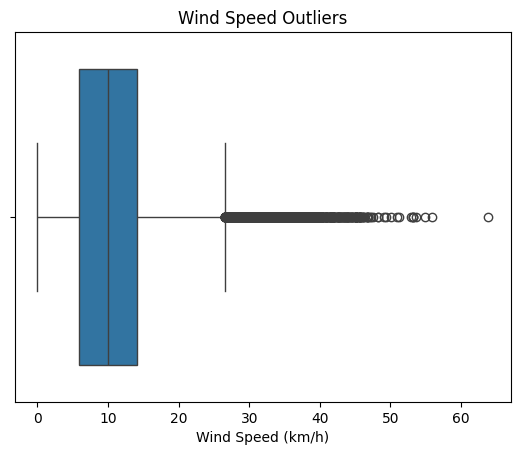

In [103]:
sns.boxplot(x=df['Wind Speed (km/h)'])
plt.title('Wind Speed Outliers')
plt.show()

Insight: Wind speed contains some high-value outliers

# **Supermarket Sales**

In [104]:
df = pd.read_csv('/content/SuperMarketAnalysis.csv')

In [105]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [107]:
df.shape

(1000, 17)

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [109]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [110]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


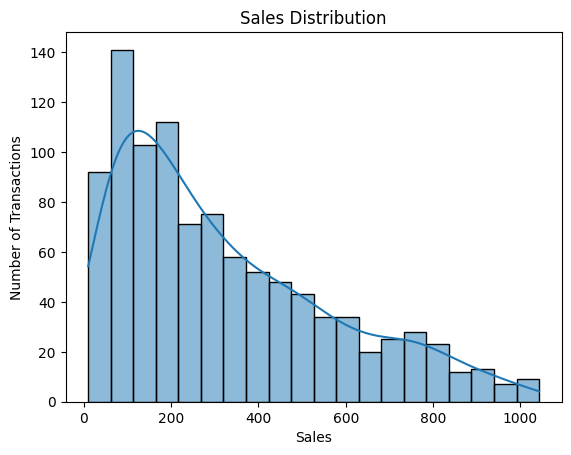

In [111]:
sns.histplot(df['Sales'], bins=20, kde=True)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Number of Transactions')
plt.show()

Insight: Most transactions have relatively low to moderate sales

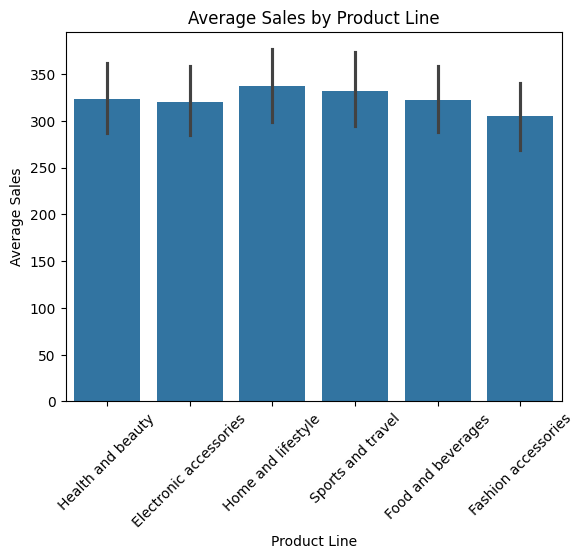

In [112]:
sns.barplot(x='Product line', y='Sales', data=df)
plt.title('Average Sales by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.show()

Insight: Different product lines have similar average sales

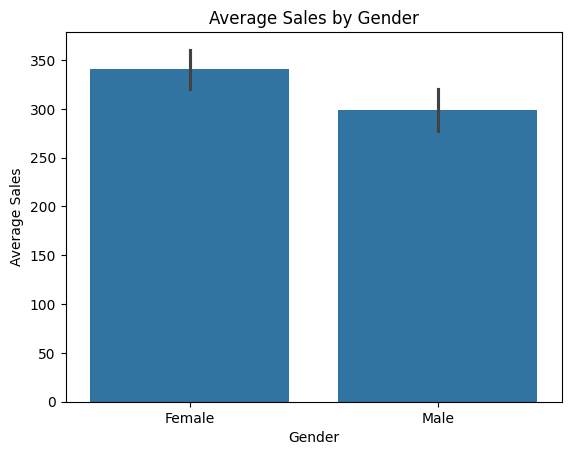

In [113]:
sns.barplot(x='Gender', y='Sales', data=df)
plt.title('Average Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Sales')
plt.show()

Insight: The average sales are fairly similar for male and female customers, with only a small difference between them.

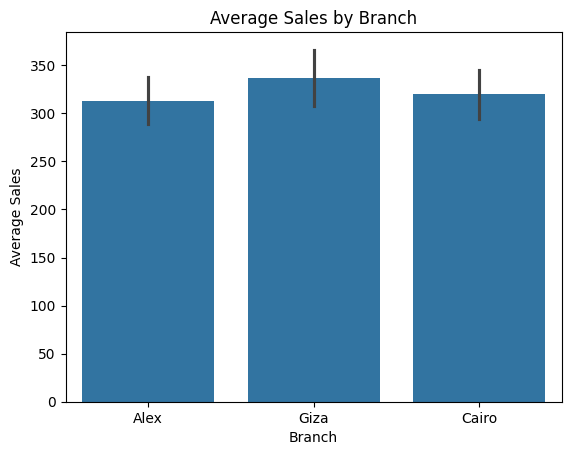

In [114]:
sns.barplot(x='Branch', y='Sales', data=df)
plt.title('Average Sales by Branch')
plt.xlabel('Branch')
plt.ylabel('Average Sales')
plt.show()

Insight: Branch C has the highest average sales, while Branch A has the lowest average sales.

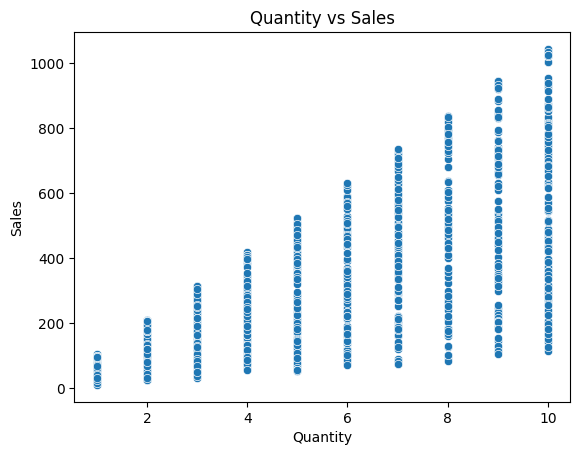

In [115]:
sns.scatterplot(x='Quantity', y='Sales', data=df)
plt.title('Quantity vs Sales')
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.show()

Insight: Sales generally increase as the quantity purchased increases

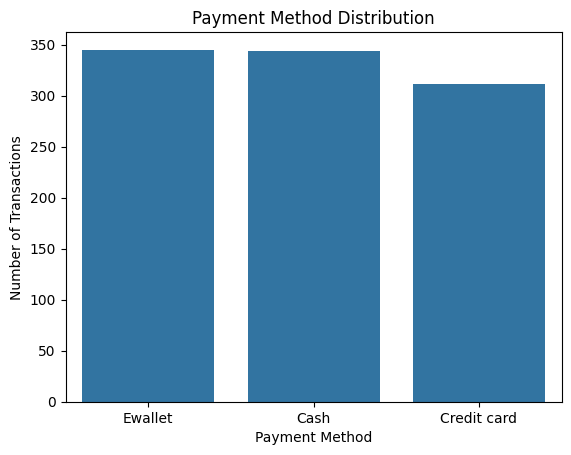

In [116]:
sns.countplot(x='Payment', data=df)
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.show()

Insight: Ewallet, cash, and credit card are all commonly used, with only small differences in their usage.

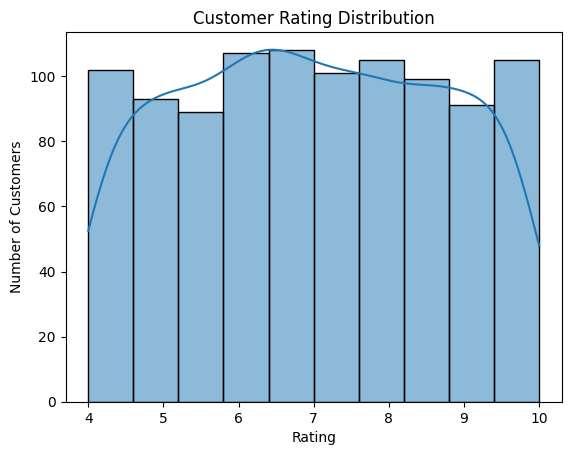

In [117]:
sns.histplot(df['Rating'], bins=10, kde=True)
plt.title('Customer Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Customers')
plt.show()

Insight: Most customer ratings are concentrated between 6 and 8, indicating generally positive customer satisfaction.

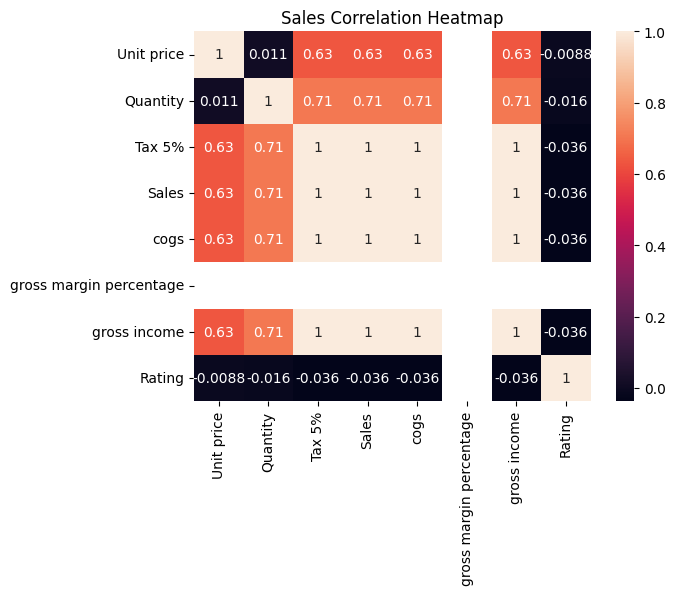

In [118]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Sales Correlation Heatmap')
plt.show()

Insight: Sales has a strong positive correlation with quantity, unit price, tax, and gross income.

In [119]:
df = df.drop('gross margin percentage', axis=1)

In [120]:
df.shape

(1000, 16)

In [121]:
df.duplicated().sum()

np.int64(0)

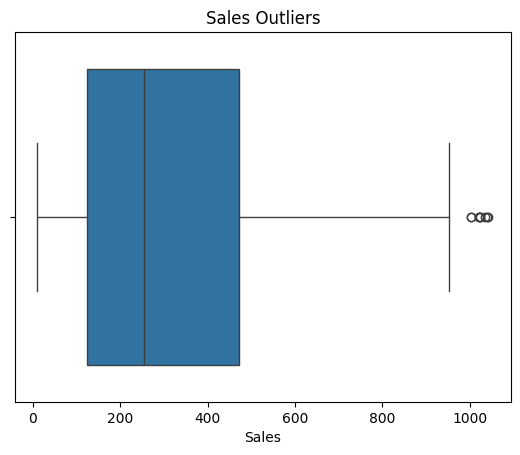

In [122]:
sns.boxplot(x=df['Sales'])
plt.title('Sales Outliers')
plt.show()

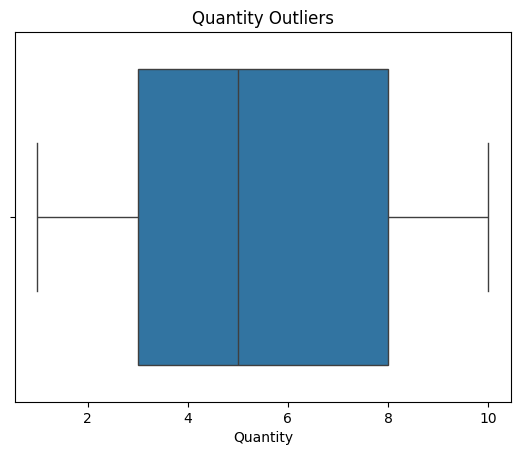

In [123]:
sns.boxplot(x=df['Quantity'])
plt.title('Quantity Outliers')
plt.show()

# **5.STUDENT PERFORMANCE DATASET**

In [125]:
df = pd.read_csv('/content/studentPerformance.csv')

In [126]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [127]:
df.shape

(649, 33)

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [129]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [130]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


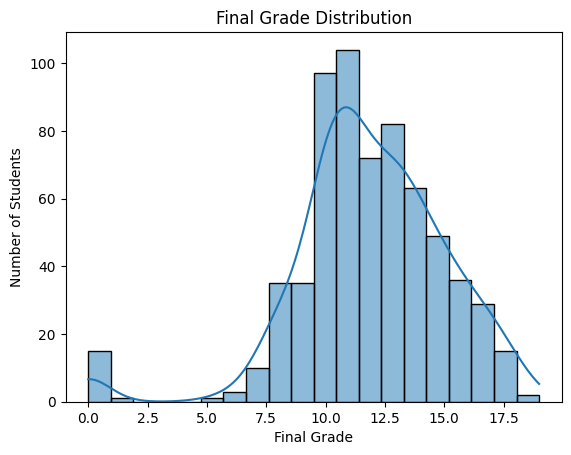

In [131]:
sns.histplot(df['G3'], bins=20, kde=True)
plt.title('Final Grade Distribution')
plt.xlabel('Final Grade')
plt.ylabel('Number of Students')
plt.show()

Insight: Most students have final grades around 10–14

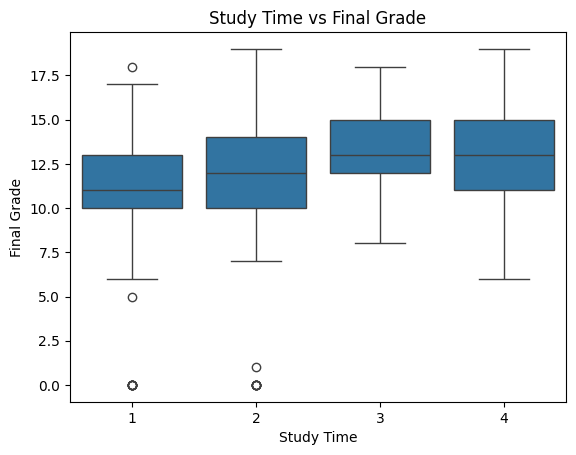

In [132]:
sns.boxplot(x='studytime', y='G3', data=df)
plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time')
plt.ylabel('Final Grade')
plt.show()

Insight: Students with more study time generally have slightly higher final grades.

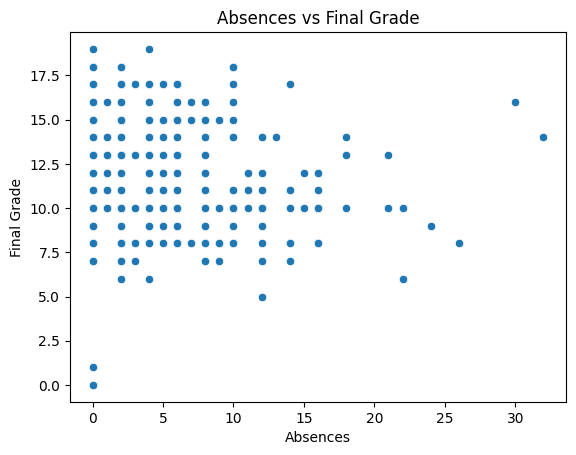

In [133]:
sns.scatterplot(x='absences', y='G3', data=df)
plt.title('Absences vs Final Grade')
plt.xlabel('Absences')
plt.ylabel('Final Grade')
plt.show()

Insight: Students with fewer absences generally tend to have higher final grades, although the relationship is not very strong

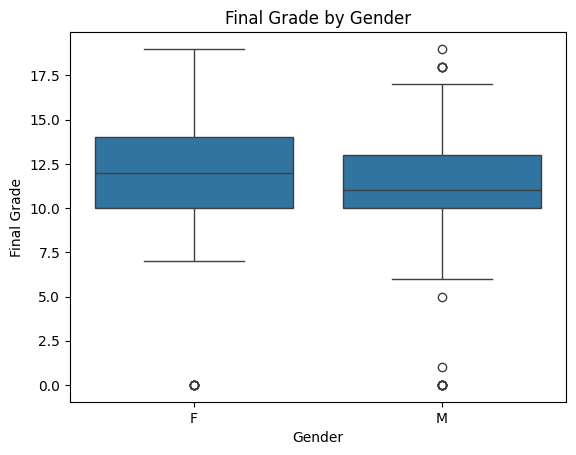

In [134]:
sns.boxplot(x='sex', y='G3', data=df)
plt.title('Final Grade by Gender')
plt.xlabel('Gender')
plt.ylabel('Final Grade')
plt.show()

Insight: Female students have a slightly higher median final grade than male students.

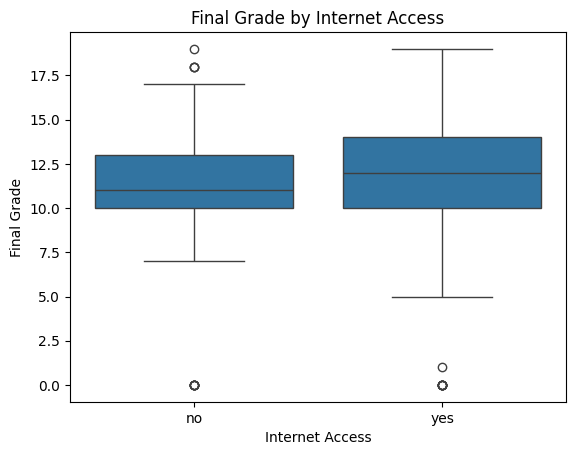

In [135]:
sns.boxplot(x='internet', y='G3', data=df)
plt.title('Final Grade by Internet Access')
plt.xlabel('Internet Access')
plt.ylabel('Final Grade')
plt.show()

Insight: Students with internet access generally have slightly higher final grades than those without internet access.

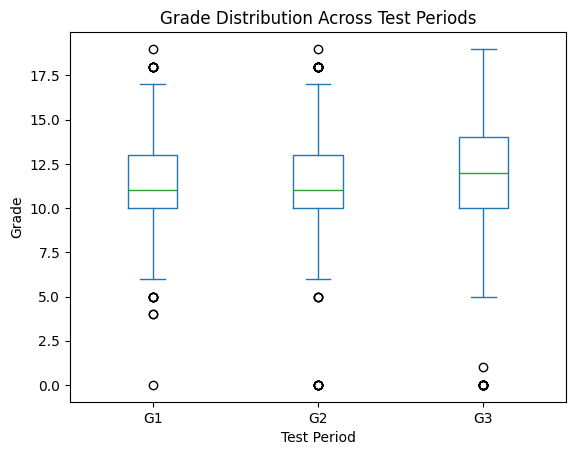

In [136]:
df[['G1', 'G2', 'G3']].plot(kind='box')
plt.title('Grade Distribution Across Test Periods')
plt.xlabel('Test Period')
plt.ylabel('Grade')
plt.show()

Insight: The distributions of G1, G2, and G3 are similar, with the median grade increasing slightly from G1 to G3.

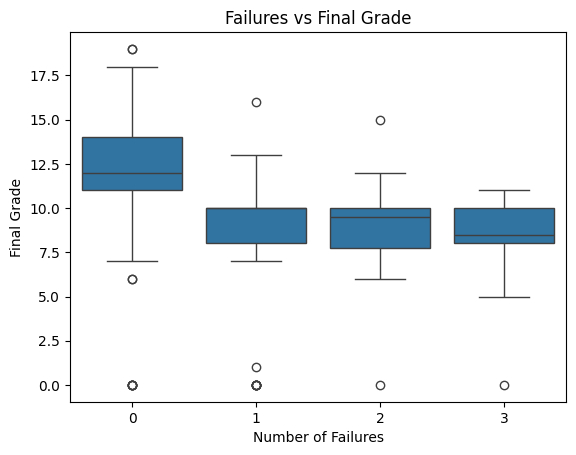

In [137]:
sns.boxplot(x='failures', y='G3', data=df)
plt.title('Failures vs Final Grade')
plt.xlabel('Number of Failures')
plt.ylabel('Final Grade')
plt.show()

Insight: Students with fewer previous failures generally have higher final grades, while students with more failures tend to have lower final grades.

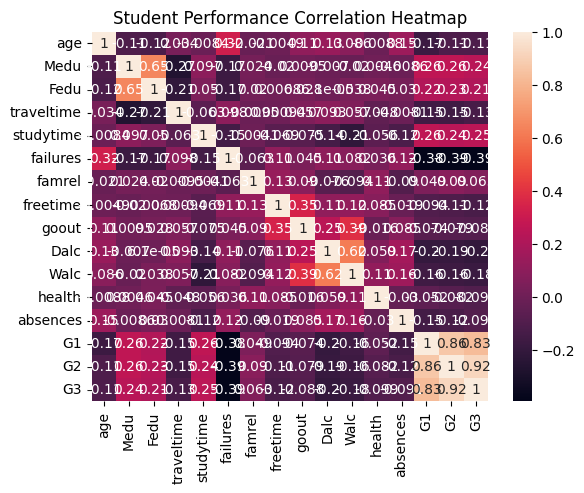

In [139]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Student Performance Correlation Heatmap')
plt.show()

Insight: G1 and G2 have strong positive correlations with G3, while absences and failures show negative relationships with the final grade.

In [140]:
df.duplicated().sum()

np.int64(0)

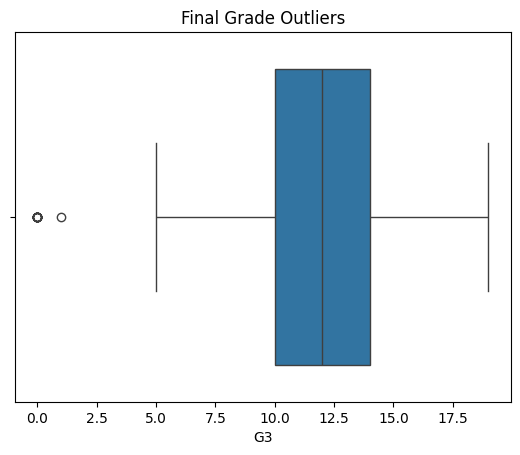

In [141]:
sns.boxplot(x=df['G3'])
plt.title('Final Grade Outliers')
plt.show()

Insight: The box plot can help identify unusually low or high final grades. However, since grades naturally range from 0 to 20, we should not remove valid extreme grades automatically.

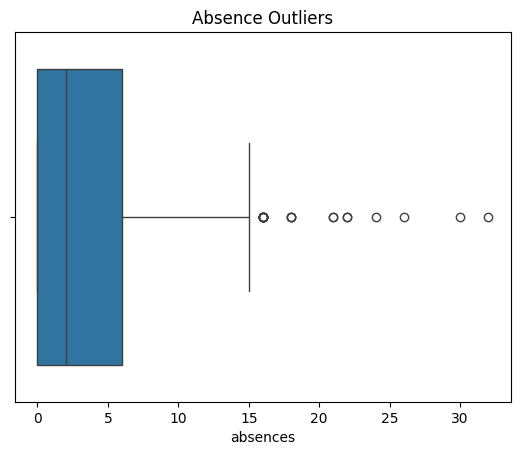

In [142]:
sns.boxplot(x=df['absences'])
plt.title('Absence Outliers')
plt.show()

Insight: There are some students with unusually high numbers of absences, which appear as outliers.